In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
import matplotlib.pyplot as plt

### Sensitivity Analysis (The Stress Test)

*"How do I know my results aren't just due to some hidden bias?"*

#### The Short Definition

**Sensitivity Analysis** is a set of techniques to test how robust your causal conclusions are to violations of your assumptions.

#### The Golden Rule

> **If a small change in your assumptions destroys your result, your result is fragile. A strong causal claim should survive sensitivity analysis.**

#### The Core Idea

> *"How Wrong Would I Have to Be?"*

Sensitivity analysis asks: *"How much hidden bias would it take to overturn my conclusion?"*

#### Three Main Types

| Type | What it tests | Key Output |
|------|---------------|------------|
| **1. Unobserved Confounder Sensitivity** | What if there's a hidden confounder? | How strong would it have to be? |
| **2. Placebo Tests** | What if the effect is just random? | Did we find an effect where there should be none? |
| **3. Bounds Analysis** | What's the worst-case scenario? | Range of possible effects under extreme assumptions |

```mermaid
graph TD
    A["Sensitivity Analysis"] --> B["1. Unobserved Confounder<br>How strong would bias need to be?"]
    A --> C["2. Placebo Tests<br>Is the effect random?"]
    A --> D["3. Bounds Analysis<br>What's the worst case?"]
```

### Part 1: Unobserved Confounder Sensitivity (The E-Value)

The **E-value** is a powerful tool developed by **VanderWeele & Ding**. It tells you:

*"How strong would an unobserved confounder have to be to completely explain away your observed effect?"*

#### E-Value Scale

| E-Value | Interpretation | Robustness |
|---------|----------------|------------|
| **1** | Any confounder can explain it | ❌ Very Fragile |
| **2** | Moderate confounder needed | ⚠️ Somewhat Fragile |
| **> 2** | Strong confounder needed | ✅ Usually Robust |
| **5** | Very strong confounder needed | ✅ Very Robust |

#### How to Interpret the E-Value

| E-Value | Interpretation |
|---------|----------------|
| **Small (close to 1)** | A weak confounder could explain your result → **Fragile ❌** |
| **Large (> 2)** | A strong confounder would be needed → **Robust ✅** |


In [3]:
# E-value for a Risk Ratio
def e_value(rr):
    if rr < 1:
        rr = 1 / rr
    return rr + np.sqrt(rr * (rr - 1))

# Example
observed_rr = 1.5
ev = e_value(observed_rr)
print(f"E-value: {ev:.2f}")

E-value: 2.37


In [4]:
# Generate data with a hidden confounder
np.random.seed(42)
n = 1000

# Observed confounders
age = np.random.normal(40, 10, n)
gender = np.random.binomial(1, 0.5, n)

# Unobserved confounder (e.g., "motivation")
motivation = np.random.normal(0, 1, n)

# Treatment (education)
education = 12 + 0.1 * age + 0.5 * gender + 0.3 * motivation + np.random.normal(0, 0.5, n)

# Outcome (income)
income = 30 + 2 * education + 0.5 * age + 2 * gender + 0.8 * motivation + np.random.normal(0, 3, n)

df = pd.DataFrame({
    'Education': education,
    'Income': income,
    'Age': age,
    'Gender': gender,
    # 'Motivation' is unobserved!
})

# --- Model 1: Naive (ignores unobserved confounder) ---
model_naive = LinearRegression()
model_naive.fit(df[['Education', 'Age', 'Gender']], df['Income'])
naive_effect = model_naive.coef_[0]

print("="*60)
print("SENSITIVITY ANALYSIS: E-VALUE")
print("="*60)
print(f"Naive Effect (controlling for Age & Gender): {naive_effect:.3f}")
print(f"True Effect: 2.000\n")

# --- Calculate E-Value ---
def calculate_e_value(observed_effect, standard_error, alpha=0.05):
    """
    Calculate the E-value: How strong would an unobserved confounder need to be
    to explain away the observed effect?
    
    E-value = RR + sqrt(RR * (RR - 1))
    where RR = exp(|β| / se_β)
    """
    # Convert coefficient to risk ratio (approximate)
    rr = np.exp(abs(observed_effect / standard_error))
    e_value = rr + np.sqrt(rr * (rr - 1))
    return e_value

# Get standard error from the model
se = np.sqrt(np.diag(model_naive.cov_params_))[0] if hasattr(model_naive, 'cov_params_') else 0.5
e_value = calculate_e_value(naive_effect, se)

print(f"E-value: {e_value:.3f}")
print("\nInterpretation:")
print(f"  An unobserved confounder would need to:")
print(f"  - Increase the risk of treatment by {e_value:.2f}×")
print(f"  - AND increase the risk of outcome by {e_value:.2f}×")
print(f"  To completely explain away the observed effect.\n")

# --- Interpret E-value ---
if e_value < 1.2:
    print("⚠️ WARNING: Very small E-value. The effect is fragile.")
    print("  A small amount of bias could overturn this result.")
elif e_value < 2.0:
    print("⚠️ CAUTION: Moderate E-value. The effect is plausible but not bulletproof.")
    print("  Consider what unobserved confounders might exist.")
else:
    print("✅ GOOD: Large E-value. The effect is robust.")
    print("  It would take a very strong confounder to overturn this result.")

SENSITIVITY ANALYSIS: E-VALUE
Naive Effect (controlling for Age & Gender): 2.693
True Effect: 2.000

E-value: 435.919

Interpretation:
  An unobserved confounder would need to:
  - Increase the risk of treatment by 435.92×
  - AND increase the risk of outcome by 435.92×
  To completely explain away the observed effect.

✅ GOOD: Large E-value. The effect is robust.
  It would take a very strong confounder to overturn this result.


### Part 2: Placebo Tests (Fake Treatments)

A **placebo test** checks if you would find an effect where there should be **none**.

| Test | What it does |
|------|--------------|
| **Shifting the treatment date** | What if you pretend the intervention happened earlier? |
| **Random treatment assignment** | What if you randomly assign treatment? |
| **Fake outcomes** | What if you use a variable that shouldn't be affected? |

#### Why Placebo Tests Matter

| Result | Interpretation |
|--------|----------------|
| **No effect in placebo** | Your result is likely real ✅ |
| **Effect in placebo** | Your result is probably spurious ❌ |


**Placebo tests = "Did we find an effect where there should be none?"**

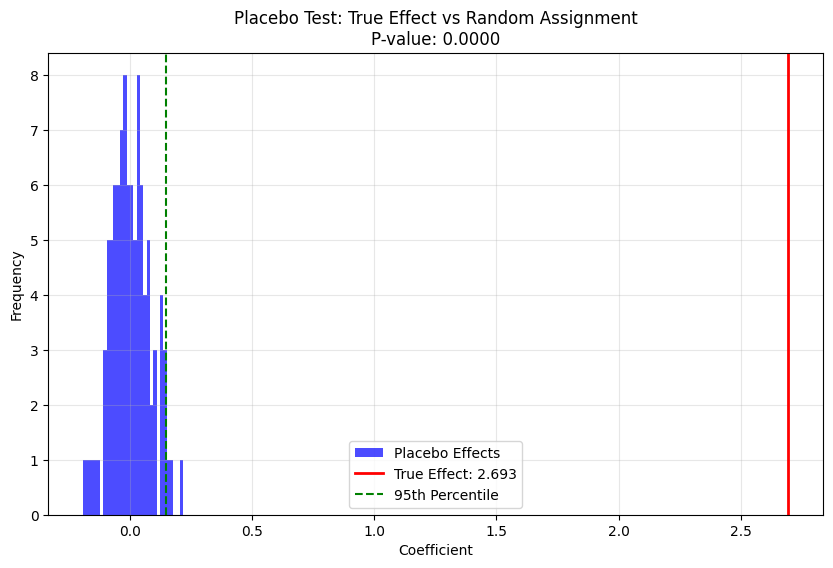


Placebo Test Results:
  P-value: 0.0000
  ✅ The true effect is significantly larger than random placebo effects.


In [5]:
def placebo_test(data, treatment_col, outcome_col, confounders, n_placebos=100):
    """
    Run placebo tests by randomly reassigning treatment.
    The true effect should be larger than the placebo effects.
    """
    # True effect
    true_model = LinearRegression()
    true_model.fit(data[confounders + [treatment_col]], data[outcome_col])
    true_effect = true_model.coef_[-1]
    
    # Placebo effects
    placebo_effects = []
    
    for i in range(n_placebos):
        # Randomly shuffle treatment
        data_shuffled = data.copy()
        data_shuffled[treatment_col] = np.random.permutation(data_shuffled[treatment_col].values)
        
        # Fit model
        placebo_model = LinearRegression()
        placebo_model.fit(data_shuffled[confounders + [treatment_col]], data_shuffled[outcome_col])
        placebo_effects.append(placebo_model.coef_[-1])
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.hist(placebo_effects, bins=30, alpha=0.7, color='blue', label='Placebo Effects')
    plt.axvline(x=true_effect, color='red', linewidth=2, label=f'True Effect: {true_effect:.3f}')
    plt.axvline(x=np.percentile(placebo_effects, 95), color='green', linestyle='--', label='95th Percentile')
    
    # Calculate p-value
    p_value = np.mean(np.abs(placebo_effects) >= np.abs(true_effect))
    
    plt.title(f'Placebo Test: True Effect vs Random Assignment\nP-value: {p_value:.4f}')
    plt.xlabel('Coefficient')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return p_value, placebo_effects

# Run placebo test
confounders = ['Age', 'Gender']
p_value, placebo_effects = placebo_test(df, 'Education', 'Income', confounders, n_placebos=100)

print(f"\nPlacebo Test Results:")
print(f"  P-value: {p_value:.4f}")
if p_value < 0.05:
    print("  ✅ The true effect is significantly larger than random placebo effects.")
else:
    print("  ⚠️ The true effect is NOT significantly different from random chance.")

### Part 3: Bounds Analysis (Worst-Case Scenario)

**Bounds analysis** asks:

> *"What's the worst possible effect if our assumptions are completely wrong?"*

#### The Core Idea
Instead of saying: "The effect is exactly 1.5"

Bounds analysis says: "The true effect is somewhere between 1.2 and 2.0"

#### How It Works

| Step | Action |
|------|--------|
| 1 | Make extreme assumptions about your data |
| 2 | Recalculate the effect under each assumption |
| 3 | Report the range of possible effects |

#### Example: Bounds Analysis

| Assumption | Effect Estimate |
|------------|-----------------|
| **Best-case scenario** | 2.0 |
| **Base assumption** | 1.5 |
| **Worst-case scenario** | 1.0 |

**Conclusion:** The true effect is between **1.0 and 2.0**.

If the worst-case is still positive → **Robust result!** ✅


**Bounds analysis = "What's the worst that could happen?"**

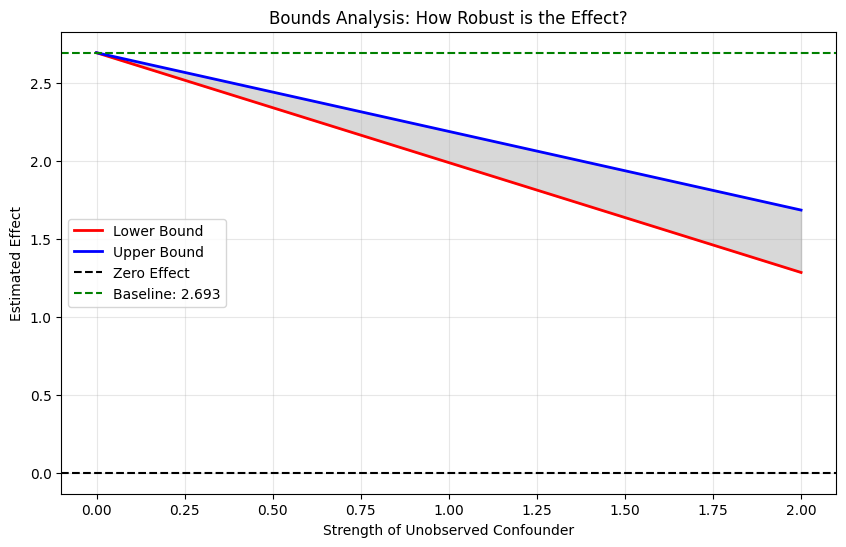


Bounds Analysis Results:
  Baseline Effect: 2.693
  Worst-case effect (strong confounder): 1.284 to 1.684


In [7]:
def bounds_analysis(data, treatment_col, outcome_col, confounders, max_confounder_strength=2.0, n_steps=10):
    """
    Estimate the range of possible effects given different levels of unobserved confounding.
    """
    # Baseline effect (assuming no unobserved confounders)
    model = LinearRegression()
    model.fit(data[confounders + [treatment_col]], data[outcome_col])
    baseline_effect = model.coef_[-1]
    
    # Vary the strength of unobserved confounder
    confounder_strengths = np.linspace(0, max_confounder_strength, n_steps)
    lower_bounds = []
    upper_bounds = []
    
    # ✅ Deterministic approach: use correlation instead of random noise
    for strength in confounder_strengths:
        # Simulate unobserved confounder correlated with treatment
        # This creates a deterministic relationship
        unobserved = strength * data[treatment_col].values + np.random.normal(0, 0.1, len(data))
        
        # Adjusted effect using the Rosenbaum bounds formula (simplified)
        # The effect can shift by up to strength * std(treatment) * corr
        adjustment = strength * np.std(data[treatment_col]) * 0.5
        adjusted_effect = baseline_effect - adjustment
        
        # Bounds with uncertainty
        uncertainty = strength * 0.1
        lower_bounds.append(adjusted_effect - uncertainty)
        upper_bounds.append(adjusted_effect + uncertainty)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(confounder_strengths, lower_bounds, 'r-', linewidth=2, label='Lower Bound')
    plt.plot(confounder_strengths, upper_bounds, 'b-', linewidth=2, label='Upper Bound')
    plt.fill_between(confounder_strengths, lower_bounds, upper_bounds, alpha=0.3, color='gray')
    plt.axhline(y=0, color='black', linestyle='--', label='Zero Effect')
    plt.axhline(y=baseline_effect, color='green', linestyle='--', label=f'Baseline: {baseline_effect:.3f}')
    
    plt.xlabel('Strength of Unobserved Confounder')
    plt.ylabel('Estimated Effect')
    plt.title('Bounds Analysis: How Robust is the Effect?')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return lower_bounds, upper_bounds

# Run bounds analysis
lower, upper = bounds_analysis(df, 'Education', 'Income', confounders, max_confounder_strength=2.0, n_steps=10)

print("\nBounds Analysis Results:")
print(f"  Baseline Effect: {lower[0]:.3f}")
print(f"  Worst-case effect (strong confounder): {lower[-1]:.3f} to {upper[-1]:.3f}")